In [48]:
import numpy as np
import scipy
from ASADmodel_true import ASAD_class
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
model = ASAD_class()
par = model.par
path = model.path

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


## 1. Single shocks

In [50]:
model.shocks(1,100,1,z=True)
model.solve()

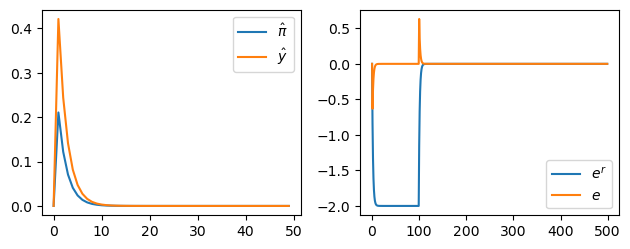

In [52]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,50,1),model.path.pihat[:50],label=r'$\hat{\pi}$')
ax.plot(range(0,50,1),model.path.yhat[:50],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

In [ ]:
model.shocks(1,100,1,s=True)
model.solve()

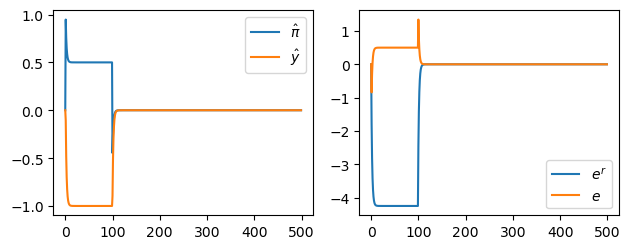

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 2. Stochastic Shocks

In [ ]:
model.stochastic_shocks(0,1,z=True)
model.solve()

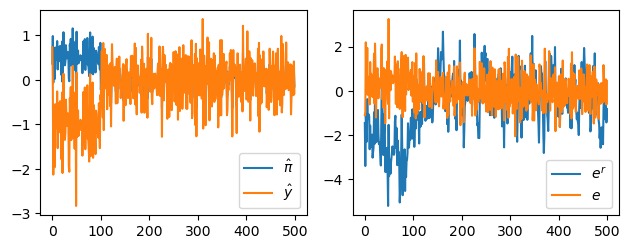

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

In [ ]:
model.stochastic_shocks(0,1,s=True)
model.solve()

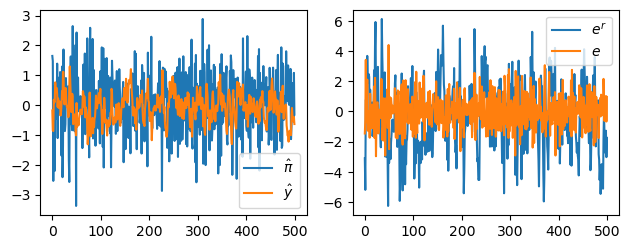

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 3. Persistent, stochastic shocks (AR)

### Demand shocks as an AR-process

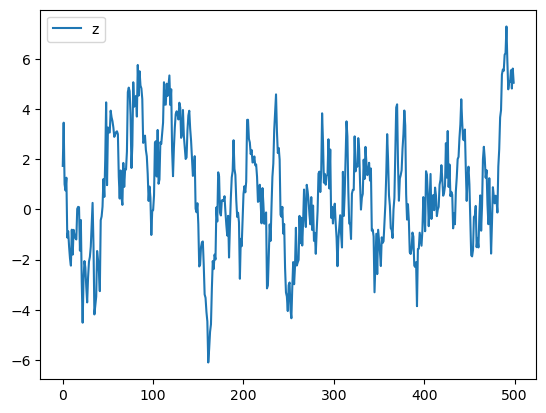

In [ ]:
model.AR_shocks(rho=0.9,sd=1,z=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r'z')
ax.legend(frameon=True)

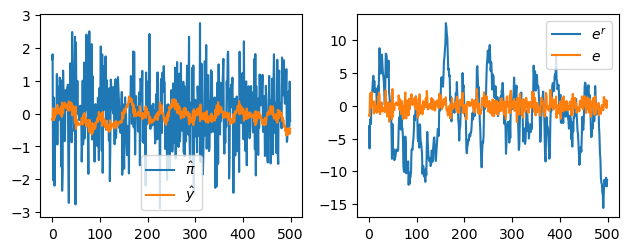

In [ ]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

### Supply shocks as an AR-process

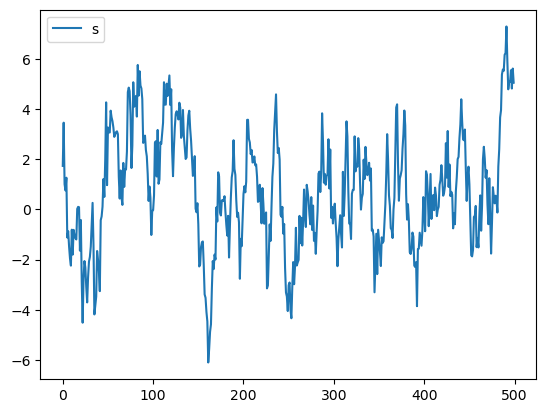

In [ ]:
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r's')
ax.legend(frameon=True)

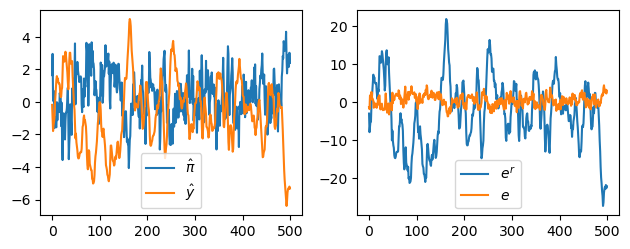

In [ ]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 4. The super, social planner, living in an AR-world

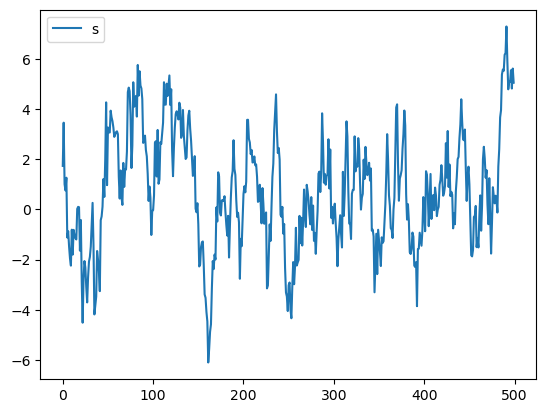

In [ ]:
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r's')
ax.legend(frameon=True)

In [ ]:
sl = np.nan*np.zeros(model.par.Tpath)
possible_h = np.arange(0,5,0.01)

def slhb(h,b):
    model.par.h = h
    model.par.b = b
    model.solve()
    return model.compute_social_loss()

In [ ]:
initial_guess = np.array(0.5,0.5)
resulthb = scipy.optimize.minimize(slhb,initial_guess)

TypeError: Cannot interpret '0.5' as a data type

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'slhb'.Shape should be (2,) but it is (500,).